# Variational Autoencoder (VAE) - MNIST Digit Generation

This project implements a Variational Autoencoder to learn a two-dimensional probabilistic latent representation of MNIST digits and generate new samples from that latent space. The model combines image reconstruction with KL-divergence regularization so that nearby latent points produce related digit structures.

## 1. Import Required Libraries

Import the libraries required for data preparation, visualization, model construction and evaluation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## 2. Load the MNIST Dataset

Load the official TensorFlow MNIST dataset, normalize pixel values, flatten the images, and create training, validation, and test splits.

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training Samples:", x_train.shape[0])
print("Validation Samples:", x_val.shape[0])
print("Test Samples:", x_test.shape[0])

Training Samples: 48000
Validation Samples: 12000
Test Samples: 10000


## 3. Explore the Dataset

Inspect representative digits and the distribution of the ten MNIST classes.

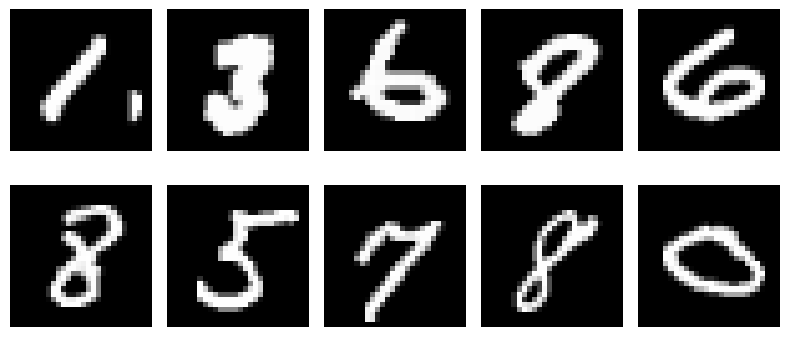

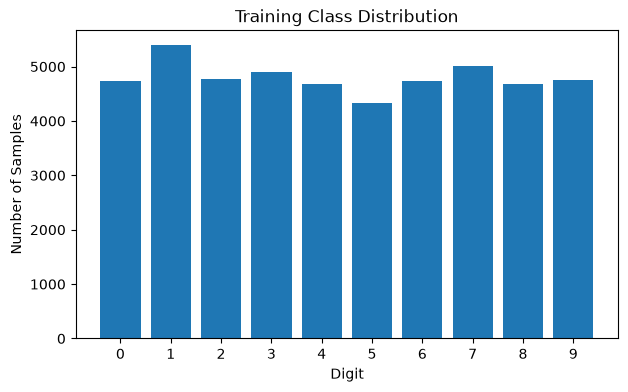

In [3]:
fig, ax = plt.subplots(2, 5, figsize=(8, 4))

for i, a in enumerate(ax.flat):
    a.imshow(x_train[i].reshape(28, 28), cmap="gray")
    a.axis("off")

plt.tight_layout()
plt.show()

classes, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(7, 4))
plt.bar(classes, counts)
plt.xlabel("Digit")
plt.ylabel("Number of Samples")
plt.title("Training Class Distribution")
plt.xticks(classes)
plt.show()

## 4. Build the Encoder and Decoder

Construct the encoder that produces the mean and log-variance of a two-dimensional latent distribution, and the decoder that maps latent samples back to images.

In [4]:
latent_dim = 2
input_dim = 784

encoder_inputs = Input(shape=(input_dim,), name="encoder_input")
x = Dense(256, activation="relu")(encoder_inputs)
x = Dense(128, activation="relu")(x)

z_mean = Dense(latent_dim, name="z_mean")(x)
z_log_var = Dense(latent_dim, name="z_log_var")(x)

def sample_latent(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = Lambda(sample_latent, name="z")([z_mean, z_log_var])

decoder_inputs = Input(shape=(latent_dim,), name="decoder_input")
decoder_x = Dense(128, activation="relu")(decoder_inputs)
decoder_x = Dense(256, activation="relu")(decoder_x)
decoder_outputs = Dense(input_dim, activation="sigmoid")(decoder_x)

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z],
    name="encoder"
)

decoder = Model(
    decoder_inputs,
    decoder_outputs,
    name="decoder"
)

encoder.summary()
decoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 234,372 (915.52 KB)

 Trainable params: 234,372 (915.52 KB)

 Non-trainable params: 0 (0.00 B)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Define the VAE

Combine the encoder and decoder and define reconstruction and KL-divergence losses.

In [5]:
class VAE(Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def _compute_losses(self, data, training=False):
        z_mean, z_log_var, z = self.encoder(data, training=training)
        reconstruction = self.decoder(z, training=training)

        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.binary_crossentropy(data, reconstruction),
                axis=-1
            )
        )

        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=-1
            )
        )

        total_loss = reconstruction_loss + kl_loss

        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._compute_losses(
                data, training=True
            )

        gradients = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        total_loss, reconstruction_loss, kl_loss = self._compute_losses(
            data, training=False
        )

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=Adam(learning_rate=1e-3))

## 6. Train the VAE

Train the model using the combined VAE objective while monitoring validation loss.

In [6]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = vae.fit(
    x_train,
    validation_data=x_val,
    epochs=30,
    batch_size=256,
    callbacks=[early_stopping]
)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

print("Best Epoch:", best_epoch)
print(f"Best Validation Loss: {history.history['val_loss'][best_epoch - 1]:.4f}")

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - kl_loss: 2.6607 - loss: 74.4529 - reconstruction_loss: 71.7922 - val_kl_loss: 2.1620 - val_loss: 61.6281 - val_reconstruction_loss: 59.4662
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - kl_loss: 2.6099 - loss: 60.1991 - reconstruction_loss: 57.5892 - val_kl_loss: 2.6931 - val_loss: 59.0221 - val_reconstruction_loss: 56.3290
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 2.9741 - loss: 58.5361 - reconstruction_loss: 55.5620 - val_kl_loss: 2.8726 - val_loss: 57.8848 - val_reconstruction_loss: 55.0122
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - kl_loss: 3.1741 - loss: 57.6067 - reconstruction_loss: 54.4326 - val_kl_loss: 3.1552 - val_loss: 57.0724 - val_reconstruction_loss: 53.9172
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - kl_loss: 3.3098 - loss: 57.0040 - reconstruction_loss: 53.6943 - val_kl_loss: 3.3415 - val_loss: 56.5849 - val_reconstruction_loss: 53.2434
Epoch 6/30
188/188 ━━━━━━━━━

## 7. Training Curves

Visualize total loss and its reconstruction and KL-divergence components.

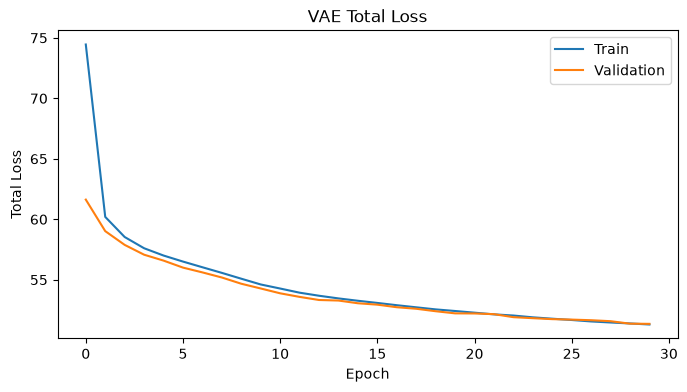

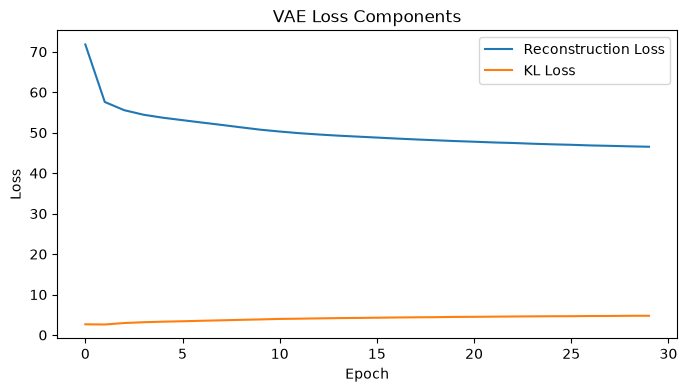

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("VAE Total Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["reconstruction_loss"], label="Reconstruction Loss")
plt.plot(history.history["kl_loss"], label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Loss Components")
plt.legend()
plt.show()

## 8. Evaluate the VAE

Evaluate the trained model on the held-out test set.

In [8]:
test_metrics = vae.evaluate(
    x_test,
    verbose=0,
    return_dict=True
)

print(f"Test Total Loss: {test_metrics['loss']:.4f}")
print(f"Test Reconstruction Loss: {test_metrics['reconstruction_loss']:.4f}")
print(f"Test KL Loss: {test_metrics['kl_loss']:.4f}")

Test Total Loss: 10.6101
Test Reconstruction Loss: 5.8647
Test KL Loss: 4.7455


## 9. Reconstruct Test Images

Reconstruct test images and compare them with the originals.

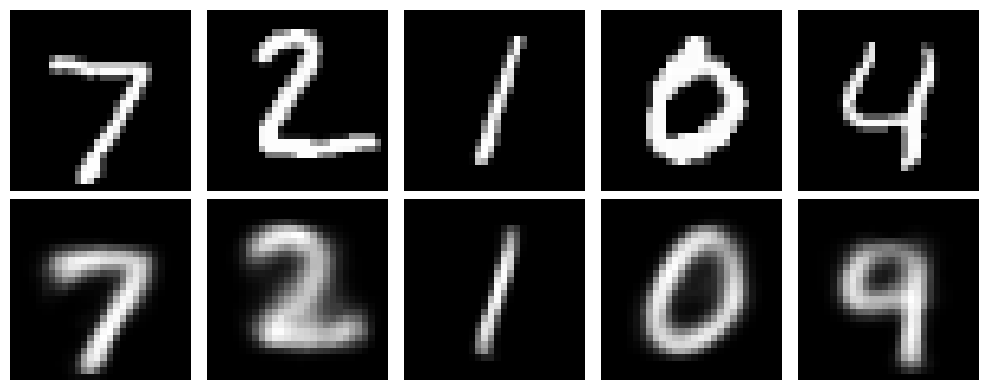

In [9]:
z_mean_test, z_log_var_test, z_test = encoder.predict(
    x_test[:10],
    verbose=0
)

reconstructed = decoder.predict(
    z_test,
    verbose=0
)

n = 5

fig, ax = plt.subplots(2, n, figsize=(10, 4))

for i in range(n):
    ax[0, i].imshow(x_test[i].reshape(28, 28), cmap="gray")
    ax[0, i].axis("off")

    ax[1, i].imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    ax[1, i].axis("off")

ax[0, 0].set_ylabel("Original")
ax[1, 0].set_ylabel("Reconstructed")

plt.tight_layout()
plt.show()

## 10. Visualize the Latent Space

Plot the two-dimensional latent representation and color points by their digit labels.

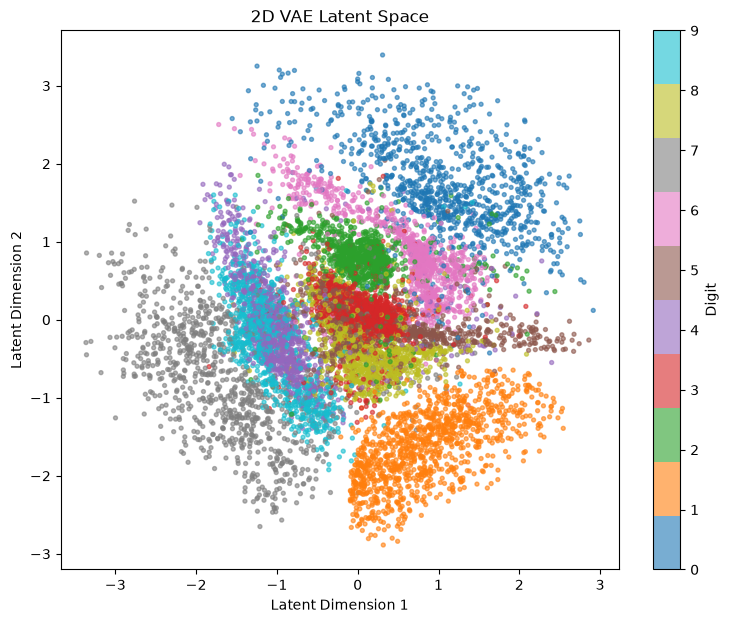

In [10]:
z_mean_all, _, _ = encoder.predict(
    x_test,
    batch_size=256,
    verbose=0
)

plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    z_mean_all[:, 0],
    z_mean_all[:, 1],
    c=y_test,
    s=8,
    alpha=0.6,
    cmap="tab10"
)

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("2D VAE Latent Space")
plt.colorbar(scatter, ticks=range(10), label="Digit")
plt.show()

## 11. Generate New Digits

Sample from the standard normal latent distribution and decode the samples into new images.

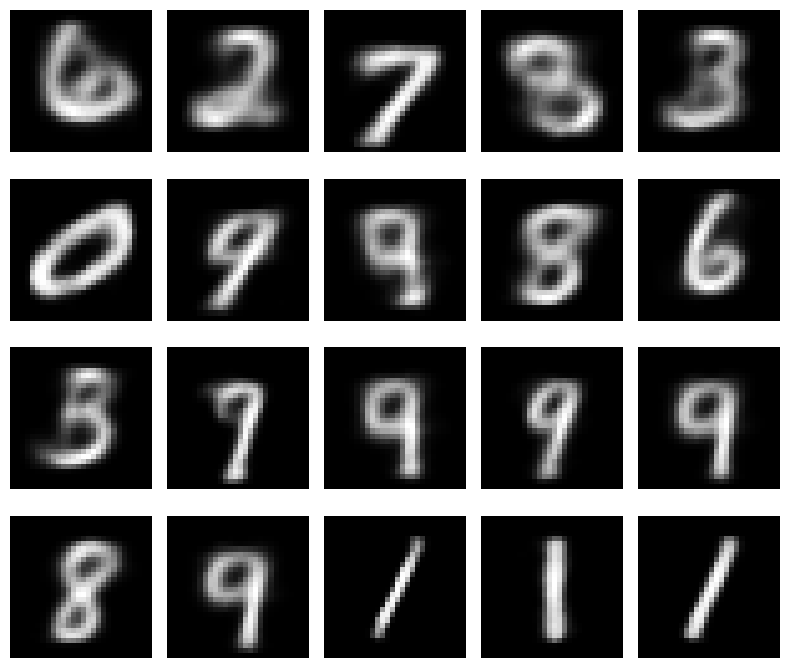

In [11]:
n = 20
random_latent = np.random.normal(
    loc=0.0,
    scale=1.0,
    size=(n, latent_dim)
).astype("float32")

generated = decoder.predict(
    random_latent,
    verbose=0
)

fig, ax = plt.subplots(4, 5, figsize=(8, 7))

for i, a in enumerate(ax.flat):
    a.imshow(generated[i].reshape(28, 28), cmap="gray")
    a.axis("off")

plt.tight_layout()
plt.show()

## 12. Latent Space Traversal

Decode a regular grid of latent coordinates to examine how generated digits change across the learned space.

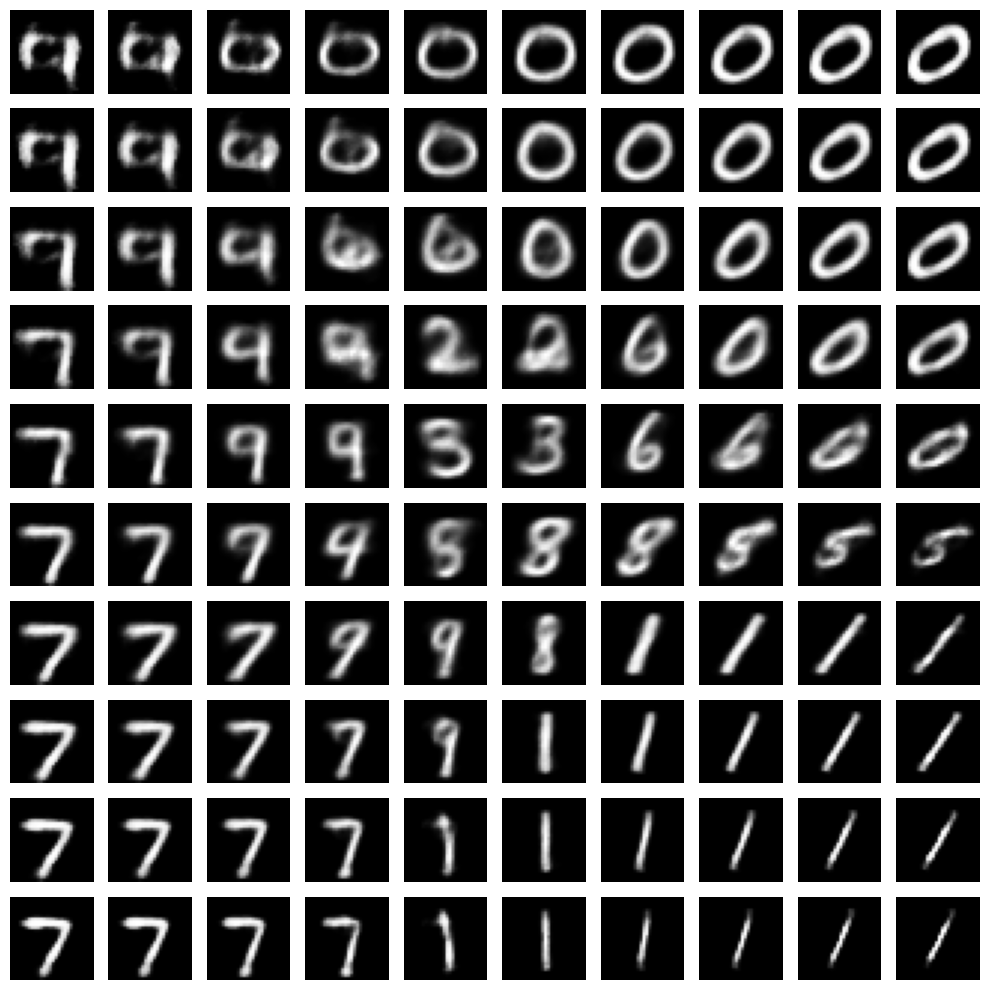

In [12]:
grid_size = 10
grid_range = 3.0

grid_x = np.linspace(-grid_range, grid_range, grid_size)
grid_y = np.linspace(-grid_range, grid_range, grid_size)

grid_latent = np.array(
    [[x, y] for y in reversed(grid_y) for x in grid_x],
    dtype="float32"
)

grid_images = decoder.predict(
    grid_latent,
    verbose=0
)

fig, ax = plt.subplots(
    grid_size,
    grid_size,
    figsize=(10, 10)
)

for i, a in enumerate(ax.flat):
    a.imshow(grid_images[i].reshape(28, 28), cmap="gray")
    a.axis("off")

plt.tight_layout()
plt.show()

# 13. Key Findings

- The VAE achieved a **test total loss of 10.6101**, consisting of a **reconstruction loss of 5.8647** and a **KL-divergence loss of 4.7455**.
- Validation loss continued to improve through the final training epoch, with the lowest recorded validation loss of **51.3550 at Epoch 30**.
- The model learned a two-dimensional latent representation in which MNIST samples form structured regions according to their digit classes.
- Sampling from the learned latent distribution produced new digit-like images, demonstrating that the model can generate samples that were not directly reconstructed from individual input images.
- Latent-space traversal produced gradual changes in the generated outputs, indicating that the learned representation captures meaningful variation in digit structure.

# 14. Conclusion

The Variational Autoencoder learned a probabilistic two-dimensional latent representation of MNIST digits while simultaneously optimizing image reconstruction and latent-space regularization. The resulting latent space showed meaningful organization of the digit classes, and random sampling from this space produced new digit-like images.

Unlike a conventional Autoencoder, the VAE does not rely on a single deterministic latent encoding for each input. The combination of the learned latent distribution and KL-divergence regularization allows the decoder to generate new samples from previously unseen points in the latent space. The results demonstrate the practical relationship between representation learning, latent-space structure, and generative modelling.